# 自前の多項式近似精度確認

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Use PennyLane-compatible implementation
from qsvt_qiskit_pennylane import block_encode_pennylane as block_encode, pc_phase, qsvt
from qiskit.quantum_info import Operator
from inverse_matrix import InverseMatrix



# Test QSVT with matrix transformation
eigvals = np.linspace(-1, 1, 16)
A_matrix = np.diag(eigvals)  # 16-dim matrix
wire_order = list(range(5))

poly_degree = 15
kappa = 20

inverse_matrix = InverseMatrix(A_matrix, poly_degree, kappa)
_, _, _, target_poly = inverse_matrix.compute_matrix_inverse_qsvt()
qc = qsvt(
    A_matrix, target_poly, encoding_wires=wire_order, block_encoding="embedding"
)  # block-encoded in 5-qubit system

U_A = Operator(qc).data
qsvt_A = np.real(np.diagonal(U_A))[:16]  # retrieve transformed eigenvalues

a_vals = np.linspace(-1, 1, 50)
target = [np.polyval(target_poly[::-1], a) for a in a_vals]
plt.plot(a_vals, target, label="target")
plt.plot(eigvals, qsvt_A, "*", label="qsvt")


# 理想関数 1/(κx)
ideal = np.zeros_like(a_vals)
mask = np.abs(a_vals) > 1e-8  # x=0 での発散を避ける
ideal[mask] = 1 / (kappa * a_vals[mask])

plt.plot(a_vals, ideal, "--", label="Ideal 1/(κx)")

plt.legend()
plt.ylim(-1,1)
plt.show()


AttributeError: 'InverseMatrix' object has no attribute 's'

# 多項式近似するためのパラメータをpennylaneから取得

In [2]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt


[dataset] = qml.data.load("other", name="inverse")
angles_qsvt = dataset.angles["qsvt"]["0.01"]["100"]
print(angles_qsvt)
print(len(angles_qsvt))


[-4.71724777  1.57110063  1.57048325  1.57111902  1.57046389  1.57113835
  1.57044463  1.57115804  1.5704243   1.5711788   1.57040337  1.57119989
  1.57038196  1.57122171  1.57035975  1.57124426  1.57033684  1.57126756
  1.57031318  1.57129151  1.57028895  1.57131607  1.57026403  1.57134137
  1.57023837  1.5713674   1.57021194  1.57139421  1.5701848   1.57142167
  1.570157    1.57144981  1.57012851  1.57147866  1.57009928  1.57150827
  1.57006929  1.57153863  1.57003857  1.5715697   1.57000714  1.57160149
  1.569975    1.571634    1.56994212  1.57166726  1.56990848  1.57170128
  1.56987408  1.57173607  1.5698389   1.57177164  1.56980294  1.57180799
  1.56976619  1.57184512  1.5697287   1.57188298  1.56969048  1.57192156
  1.56965153  1.57196088  1.56961184  1.57200094  1.5695714   1.57204176
  1.5695302   1.57208333  1.56948825  1.57212567  1.56944553  1.57216877
  1.56940204  1.57221264  1.5693578   1.57225724  1.56931284  1.57230257
  1.56926714  1.57234863  1.56922073  1.57239539  1

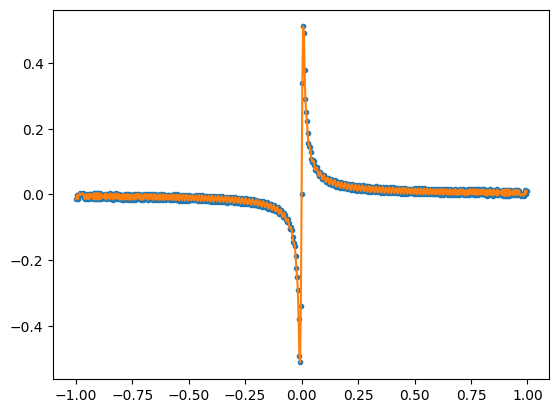

In [ ]:
outputs_qsvt = []
points = np.arange(-1, 1, 1/300)

for x in points:

    # Encode x in the top left of the matrix
    block_encoding = qml.RX(2 * np.arccos(x), wires=0)
    projectors = [qml.PCPhase(angle, dim=1, wires=0) for angle in angles_qsvt]

    @qml.qnode(qml.device("default.qubit"))
    def circuit_qsvt():
        qml.QSVT(block_encoding, projectors)
        return qml.state()

    output = qml.matrix(circuit_qsvt, wire_order=[0])()[0, 0]

    outputs_qsvt.append(output.real)

poly = np.polynomial.Chebyshev(dataset.poly['0.01']['100'])
outputs_poly = [poly(point) for point in points]

plt.plot(points, outputs_qsvt, '.')
plt.plot(points, outputs_poly)
plt.show()

# pyqspのパラメータ使用

In [1]:
import numpy as np
# 問題設定
A = np.array([3, 1, 1, 3]).reshape((2, 2))
b = np.array([1, 2], dtype="complex")

In [ ]:
from inverse_matrix_prepared_poly import InverseMatrix
from pyqsp.angle_sequence import QuantumSignalProcessingPhases
from pyqsp.poly import PolyOneOverX
import pyqsp
from qsvt_qiskit_prepared_poly import transform_angles
import numpy as np

KAPPA = 4
s = 0.10145775
EPSILON = 0.01

# 位相生成
pcoefs, s = pyqsp.poly.PolyOneOverX().generate(KAPPA, return_coef=True, ensure_bounded=True, return_scale=True)
phi_pyqsp = pyqsp.angle_sequence.QuantumSignalProcessingPhases(pcoefs, signal_operator="Wx", tolerance=0.00001)
phi_qsvt = transform_angles(phi_pyqsp, "QSP", "QSVT")

# 逆行列用の回路生成
inverse_matrix = InverseMatrix(A, kappa=KAPPA, epsilon=EPSILON)
full_unitary, qsvt_circuit, encoding_wires, phase_matrices = inverse_matrix.compute_matrix_inverse_qsvt(phi_qsvt)
print(f"phase_matrices[0][1]:\n{np.round(phase_matrices[0][1], 4)}")


b=59, j0=21
[PolyOneOverX] minimum [-4.92820307] is at [-0.14617826]: normalizing
[PolyOneOverX] bounding to 0.9
A_normalized:
 [[0.6708+0.j 0.2236+0.j]
 [0.2236+0.j 0.6708+0.j]]
block_encode_pennylane U:
 [[ 0.6708+0.j  0.2236+0.j  0.6708+0.j -0.2236+0.j]
 [ 0.2236+0.j  0.6708+0.j -0.2236+0.j  0.6708-0.j]
 [ 0.6708+0.j -0.2236+0.j -0.6708+0.j -0.2236+0.j]
 [-0.2236+0.j  0.6708-0.j -0.2236+0.j -0.6708+0.j]]
scaled_inverse_matrix:
[[ 0.2739+0.6713j -0.0913-0.0486j]
 [-0.0913-0.0486j  0.2739+0.6713j]]
full_unitary:
[[ 0.3062+0.7505j -0.1021-0.0543j -0.5595+0.j     -0.1287-0.j    ]
 [-0.1021-0.0543j  0.3062+0.7505j -0.1287-0.j     -0.5595+0.j    ]
 [-0.5595-0.j     -0.1287+0.j     -0.3062+0.7505j  0.1021-0.0543j]
 [-0.1287+0.j     -0.5595-0.j      0.1021-0.0543j -0.3062+0.7505j]]
phase_matrices[0][1]:
[[0.7071-0.7071j 0.    +0.j     0.    +0.j     0.    +0.j    ]
 [0.    +0.j     0.7071-0.7071j 0.    +0.j     0.    +0.j    ]
 [0.    +0.j     0.    +0.j     0.7071+0.7071j 0.    +0.j    ]
 

# qmlでの逆行列チェック

In [5]:
# NOTE: kappaなどは上記と同様
import pennylane as qml

# 位相生成
pcoefs, s = pyqsp.poly.PolyOneOverX().generate(KAPPA, return_coef=True, ensure_bounded=True, return_scale=True)
phi_pyqsp = pyqsp.angle_sequence.QuantumSignalProcessingPhases(pcoefs, signal_operator="Wx", tolerance=0.00001)
phi_qsvt = qml.transform_angles(phi_pyqsp, "QSP", "QSVT")


frobenius_norm = np.linalg.norm(A, ord="fro")
A_normalized = A / frobenius_norm

block_encoding = qml.BlockEncode(A_normalized, wires=range(2))
print(f"block_encoding:\n{np.round(qml.matrix(block_encoding), 4)}")


projectors = [qml.PCPhase(angle, dim=2, wires=range(2)) for angle in phi_qsvt]
print(f"projectors[0]:\n{np.round(qml.matrix(projectors[0]), 4)}")

qsvt_unitary = qml.matrix(qml.QSVT, wire_order=[0,1])(block_encoding, projectors)
print(f"qsvt_unitary:\n{np.round(qsvt_unitary, 4)}")


b=59, j0=21
[PolyOneOverX] minimum [-4.92820307] is at [-0.14617826]: normalizing
[PolyOneOverX] bounding to 0.9
block_encoding:
[[ 0.6708  0.2236  0.6708 -0.2236]
 [ 0.2236  0.6708 -0.2236  0.6708]
 [ 0.6708 -0.2236 -0.6708 -0.2236]
 [-0.2236  0.6708 -0.2236 -0.6708]]
projectors[0]:
[[0.7071-0.7071j 0.    +0.j     0.    +0.j     0.    +0.j    ]
 [0.    +0.j     0.7071-0.7071j 0.    +0.j     0.    +0.j    ]
 [0.    +0.j     0.    +0.j     0.7071+0.7071j 0.    +0.j    ]
 [0.    +0.j     0.    +0.j     0.    +0.j     0.7071+0.7071j]]
qsvt_unitary:
[[ 0.3062+0.7505j -0.1021-0.0543j -0.5595+0.j     -0.1287-0.j    ]
 [-0.1021-0.0543j  0.3062+0.7505j -0.1287-0.j     -0.5595+0.j    ]
 [-0.5595-0.j     -0.1287+0.j     -0.3062+0.7505j  0.1021-0.0543j]
 [-0.1287+0.j     -0.5595-0.j      0.1021-0.0543j -0.3062+0.7505j]]
